# Evaluate Roman kinematic lensing covariances with CoCoA

Compute **real-space and Fourier-space 3x2pt covariances**, keeping the
Gaussian (G), super-sample (SSC), connected non-Gaussian (cNG), and total
matrices separately. G describes products of power spectra and catalog
noise. SSC describes changes induced by density fluctuations larger than
the footprint. cNG describes the remaining connected four-point signal.

The project uses ten lens and ten source distributions. The Fourier
range and band count follow its dataset; the angular bins illustrate a
companion measurement. Galaxy–shear rows retain only source > lens.
The calculations share the physics in `cosmolike_notebook_utils.covariance`;
C++ exposes whole Gaussian matrices and individual C components. The C
loops use OpenMP and SIMDe; BLAS uses one thread.

**Forecast model:** massless neutrinos, linear galaxy bias, zero IA,
magnification and RSD, Limber spectra, a spherical-cap footprint and the
five-term halo trispectrum. SSC uses an isotropic halo response transferred
to the nonlinear power, with galaxy survey-mean subtraction. These choices
do not reproduce every approximation in a supplied survey covariance.
No likelihood data or covariance is loaded or replaced.

Follow [the covariance guide](covariance/README.md) to compile and start
this notebook. The physics decomposition follows
[Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and
[Takada & Hu](https://arxiv.org/abs/1302.6994).


In [1]:
import os
from pathlib import Path
import sys

# Set the BLAS policy before importing numerical libraries. OpenMP workers
# belong to the explicit C loops, not to nested BLAS matrix operations.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/roman_kl"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_roman_kl_interface as ci
import roman_kl_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils.covariance.forecast import save_forecast
from cosmolike_notebook_utils import plot_covariances as pcov

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)

# Figure appearance belongs to the notebook, not the shared plotters.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'


## Survey inputs and one accuracy control

The area, total source density of 4 galaxies per square arcminute and
quadrature shape dispersion 0.035 follow
[Xu et al.](https://arxiv.org/abs/2201.00739). The code needs dispersion
per component, so the example uses $0.035/\sqrt{2}$.
The lens catalog is an illustrative additional choice: total density 4
with the same ten redshift shapes as the sources. Both catalogs are
allocated equally among bins. These assumptions do not reproduce a
calibrated KL clustering sample or the supplied likelihood covariance.

| Measurement | Layout |
| --- | --- |
| Lens and source bins | 10 lenses, 10 sources |
| Angular bins | 20 logarithmic bins, 2.5–250 arcminutes |
| Integer Fourier bands | 20 bands, multipoles 20–4000 |
| Real-space vector | 3,300 entries |
| Fourier vector | 2,200 entries |

Internal spectra retain all crossed pairs, including pairs excluded from
measured rows. Inspect the printed settings before interpreting the noise.

`accuracy_boost` raises integration resolution together. Use 1, 2, 4 or 8;
extend `boosts` for stronger refinement. CAMB accuracy and measurement bins
stay fixed. The highest tested boost is a comparison reference, not a
certified inference setting.

The multipole and lensing-window interpolation tables retain their old
nodes when the boost doubles. New nodes split existing intervals; a
larger cutoff extends the same grid. This avoids moving the slope jumps
of the linear interpolant at each refinement. It does not guarantee
monotonic errors or replace a comparison of the highest boosts.


In [2]:
boosts = [1, 2]
settings = survey.configuration(accuracy_boost=boosts[0])
camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)

for name in ("area_deg2", "lens_density_arcmin2", "source_density_arcmin2",
             "sigma_e_component", "accuracy_boost"):
    print(name, settings[name])
print("Non-Gaussian multipole samples:", len(settings["ng_ell"]))


def progress(stage, elapsed):
    """Print completed integration stages without starting another calculation."""
    print(f"{elapsed:8.2f} s  {stage}")


area_deg2 2000.0
lens_density_arcmin2 [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4]
source_density_arcmin2 [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4]
sigma_e_component [0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162, 0.024748737341529162]
accuracy_boost 1
Non-Gaussian multipole samples: 16


## Real-space Gaussian, SSC and connected covariance

All angular bins of one observable are consecutive. Observable rows run
through $\xi_+$, $\xi_-$, $\gamma_t$, then $w$. Pure white noise has an
infinite harmonic tail, so the real-space calculation uses analytic pair
noise; signal and mixed noise retain the finite multipole sum.

The following loop holds the physical inputs fixed and raises only the
covariance resolution. Each returned dictionary contains `gaussian`,
`ssc`, `cng`, `total`, mean `signal`, row labels and resolved `settings`.


Real-space accuracy boost 1


    0.28 s  all_pairs_limber_spectra
    0.31 s  angular_and_mask_geometry


    3.15 s  gaussian_blocks
    3.16 s  observable_signal
    3.18 s  Matter shell 1/448
    3.29 s  Matter shell 33/448


    3.40 s  Matter shell 65/448
    3.51 s  Matter shell 97/448


    3.62 s  Matter shell 129/448
    3.73 s  Matter shell 161/448


...

   14.58 s  Matter shell 801/896


   14.96 s  Matter shell 833/896


   15.34 s  Matter shell 865/896


   15.72 s  shared_halo_response_and_trispectrum


   16.65 s  ssc_and_connected_projection
   16.67 s  total


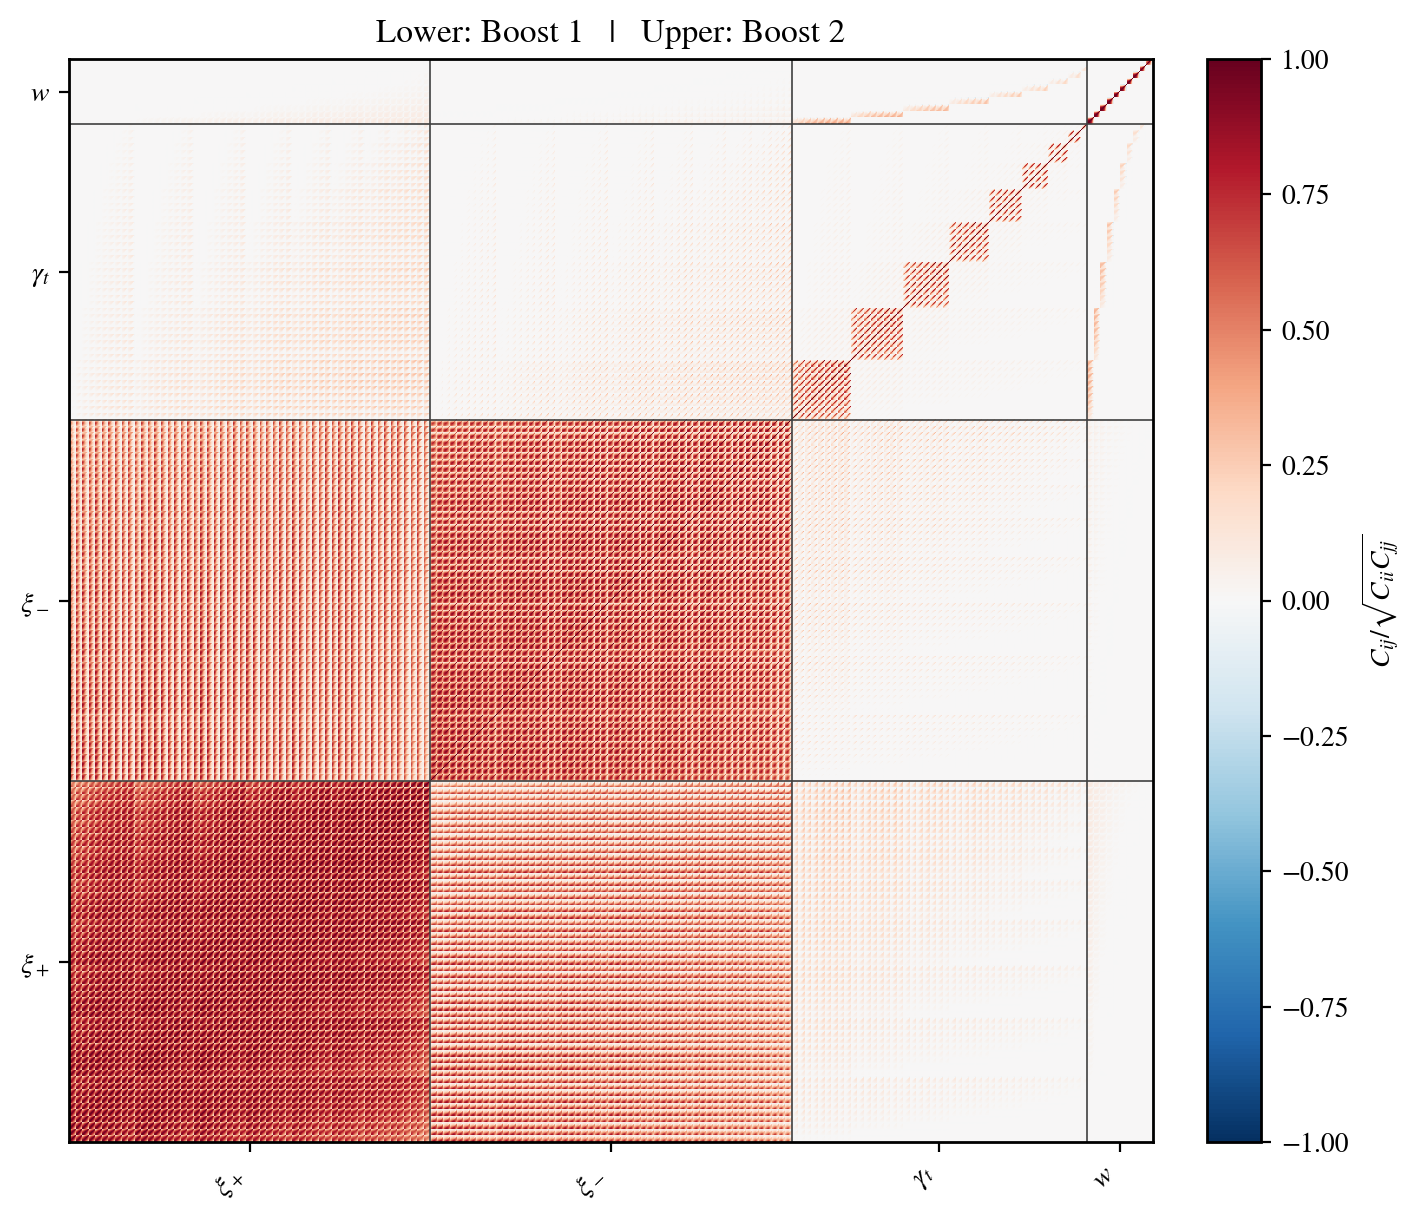

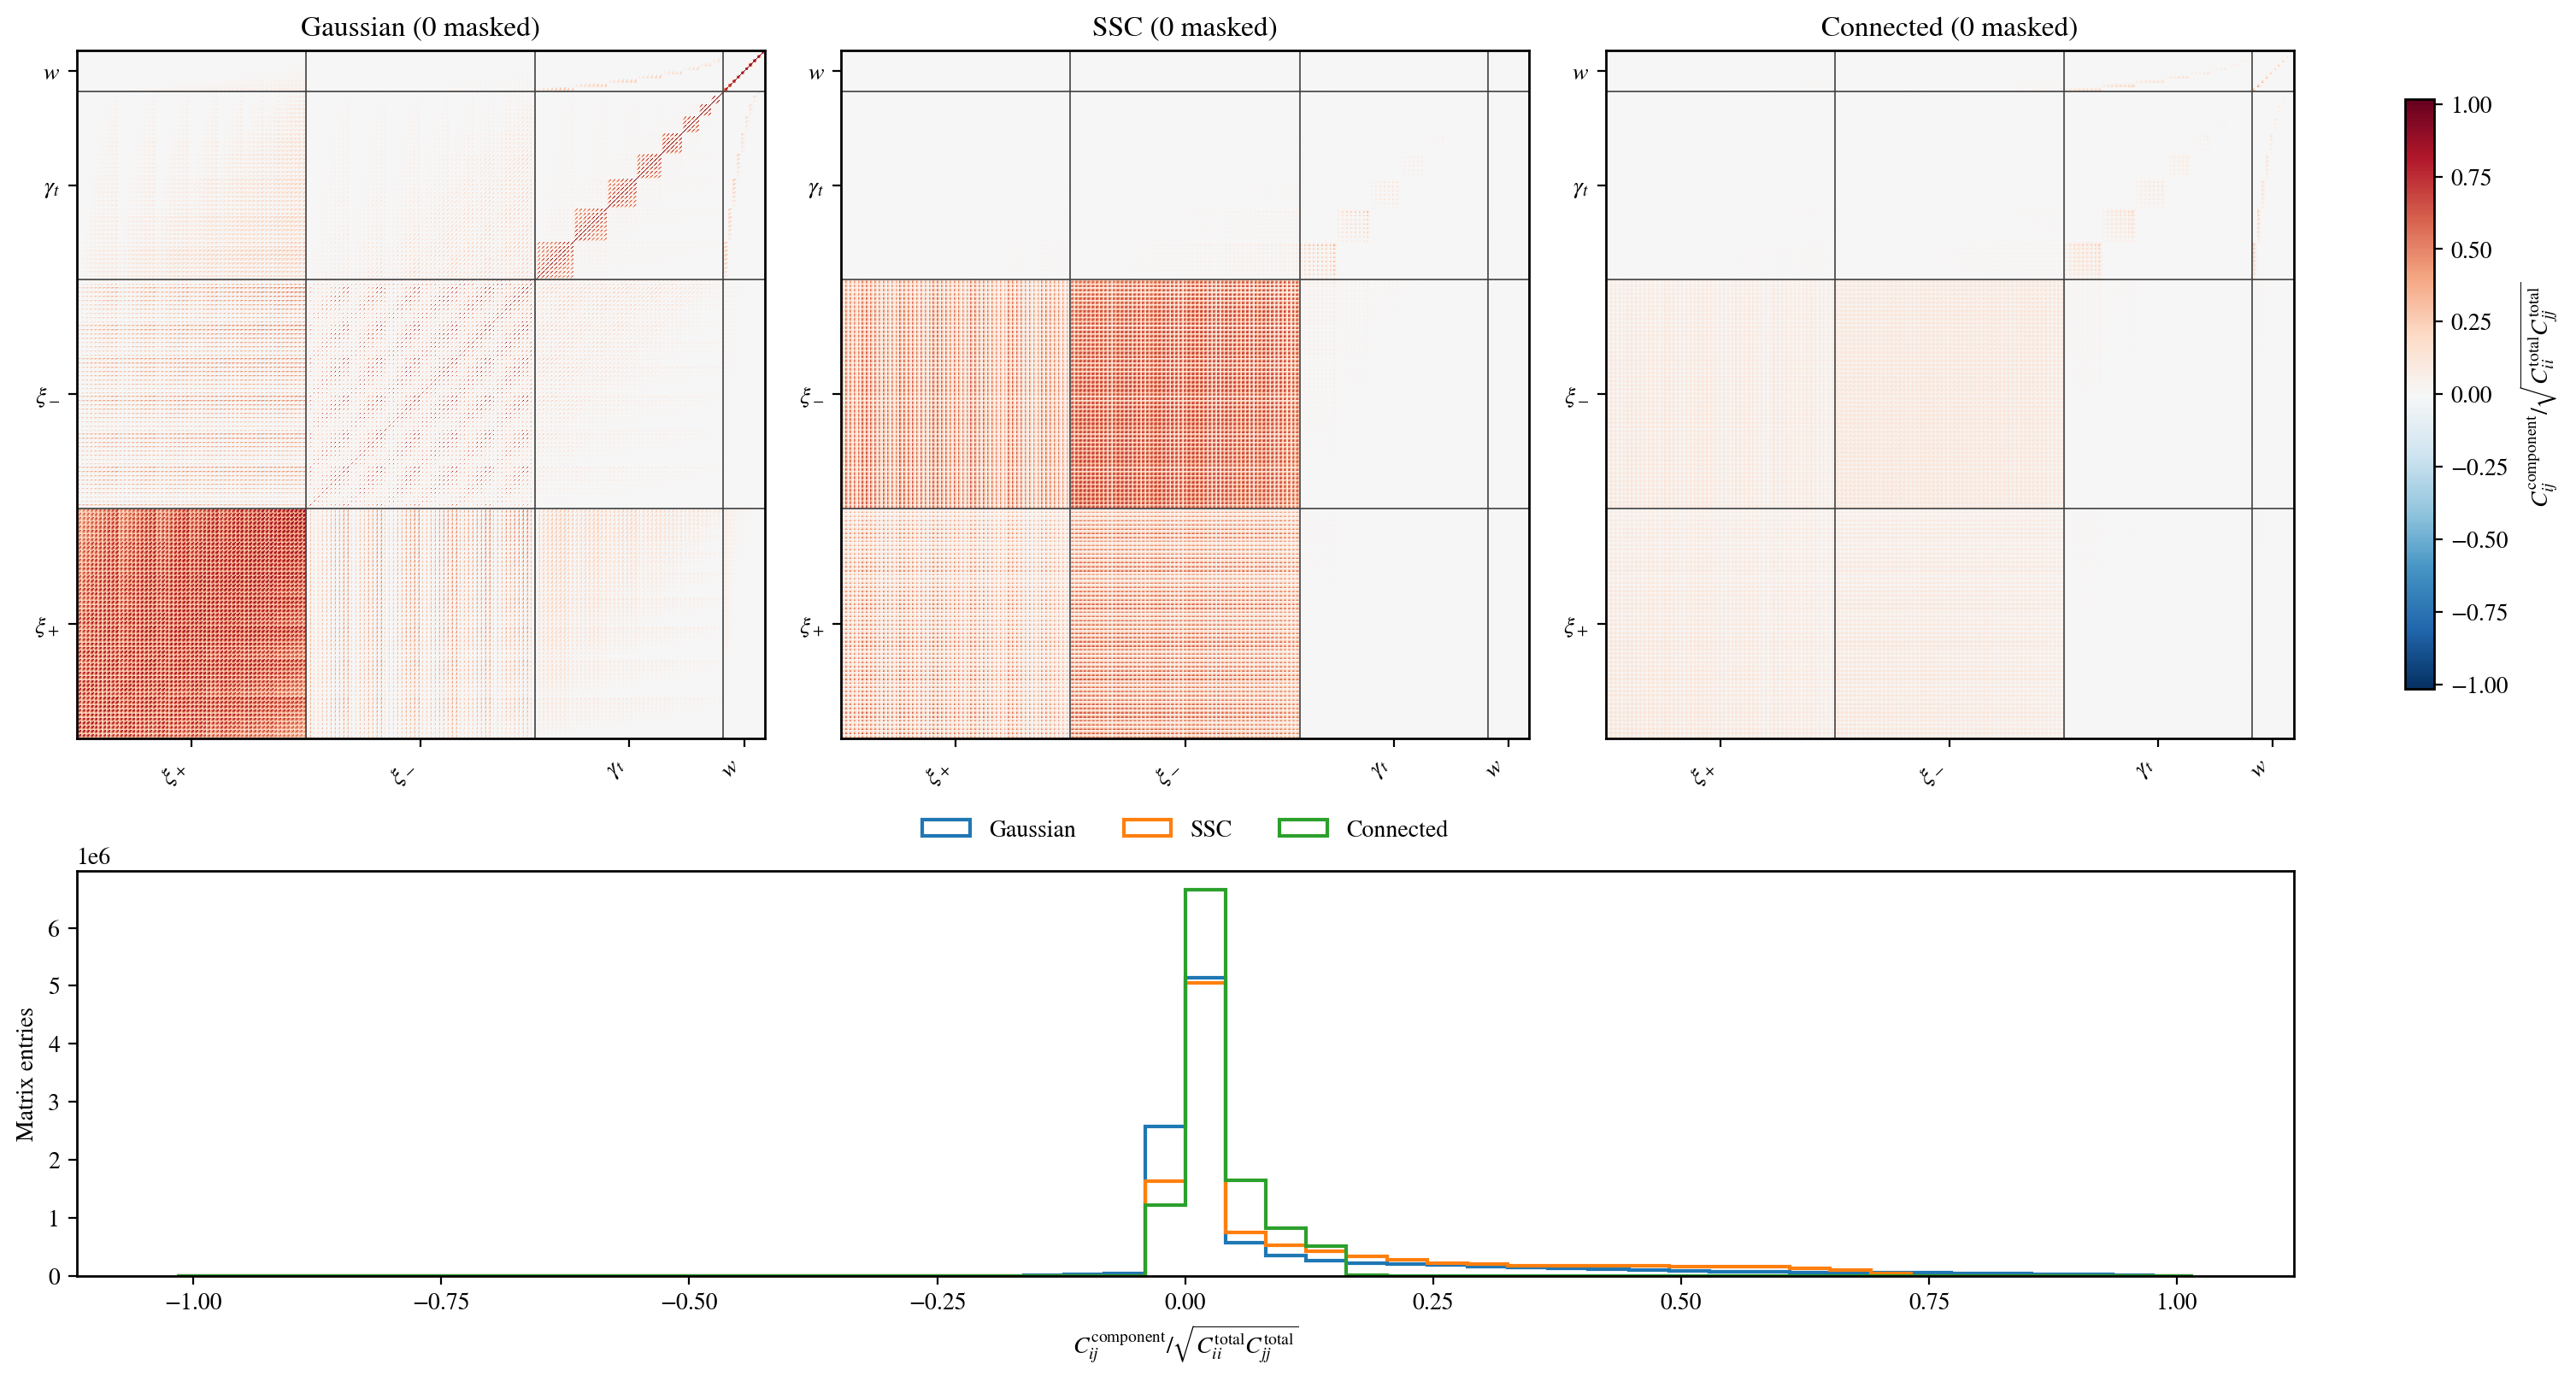

In [3]:
real_results = {}
for boost in boosts:
    refined = dict(settings)
    refined.update(cov.covariance_accuracy(accuracy_boost=boost))
    print("Real-space accuracy boost", boost)
    real_results[boost] = survey.compute(
        interface=ci, settings=refined, space="real", progress=progress
    )

reference_boost = boosts[-1]
real = real_results[reference_boost]
nbin = len(real["coordinate"])
real_sizes = []
for probe in (0, 1, 2, 3):
    real_sizes.append(int(np.sum(real["rows"][:, 0] == probe))*nbin)
real_labels = [r"$\xi_+$", r"$\xi_-$", r"$\gamma_t$", r"$w$"]
pcov.plot_correlation(
    covariance=real_results[boosts[0]]["total"],
    covariance_ref=real["total"], block_sizes=real_sizes,
    block_labels=real_labels,
    labels=(f"Boost {boosts[0]}", f"Boost {reference_boost}"),
)
pcov.plot_covariance_components(
    total=real["total"],
    components={
        "Gaussian": real["gaussian"],
        "SSC": real["ssc"],
        "Connected": real["cng"],
    },
    block_sizes=real_sizes, block_labels=real_labels,
    normalization="diagonal",
)


## Fourier bandpowers

A band averages its integer multipoles with weight $2\ell+1$, their number
of harmonic modes. The Gaussian term includes finite-band white noise.
SSC and cNG use the same matter calculation as the angular forecast,
projected through band weights on both matrix axes.

There is one shear E-mode spectrum per source pair; do not duplicate it
for $\xi_+$ and $\xi_-$. Fourier means average the core spectra directly.
Real-space means include the extra source-leg factor needed to match
Cocoa's angular transformation convention. Each space applies its chosen
normalization consistently to G, SSC and cNG. Thus the examples should not
be compared as if their vectors contained the same measurements.


Fourier accuracy boost 1
    0.10 s  all_pairs_limber_spectra
    0.10 s  angular_and_mask_geometry


    1.07 s  gaussian_blocks
    1.07 s  observable_signal
    1.08 s  Matter shell 1/448
    1.18 s  Matter shell 33/448


    1.28 s  Matter shell 65/448
    1.38 s  Matter shell 97/448
    1.48 s  Matter shell 129/448


    1.58 s  Matter shell 161/448
    1.67 s  Matter shell 193/448
    1.77 s  Matter shell 225/448


    1.87 s  Matter shell 257/448
    1.97 s  Matter shell 289/448
    2.08 s  Matter shell 321/448


...

   10.16 s  Matter shell 801/896


   10.52 s  Matter shell 833/896


   10.89 s  Matter shell 865/896


   11.24 s  shared_halo_response_and_trispectrum


   11.71 s  ssc_and_connected_projection
   11.71 s  total


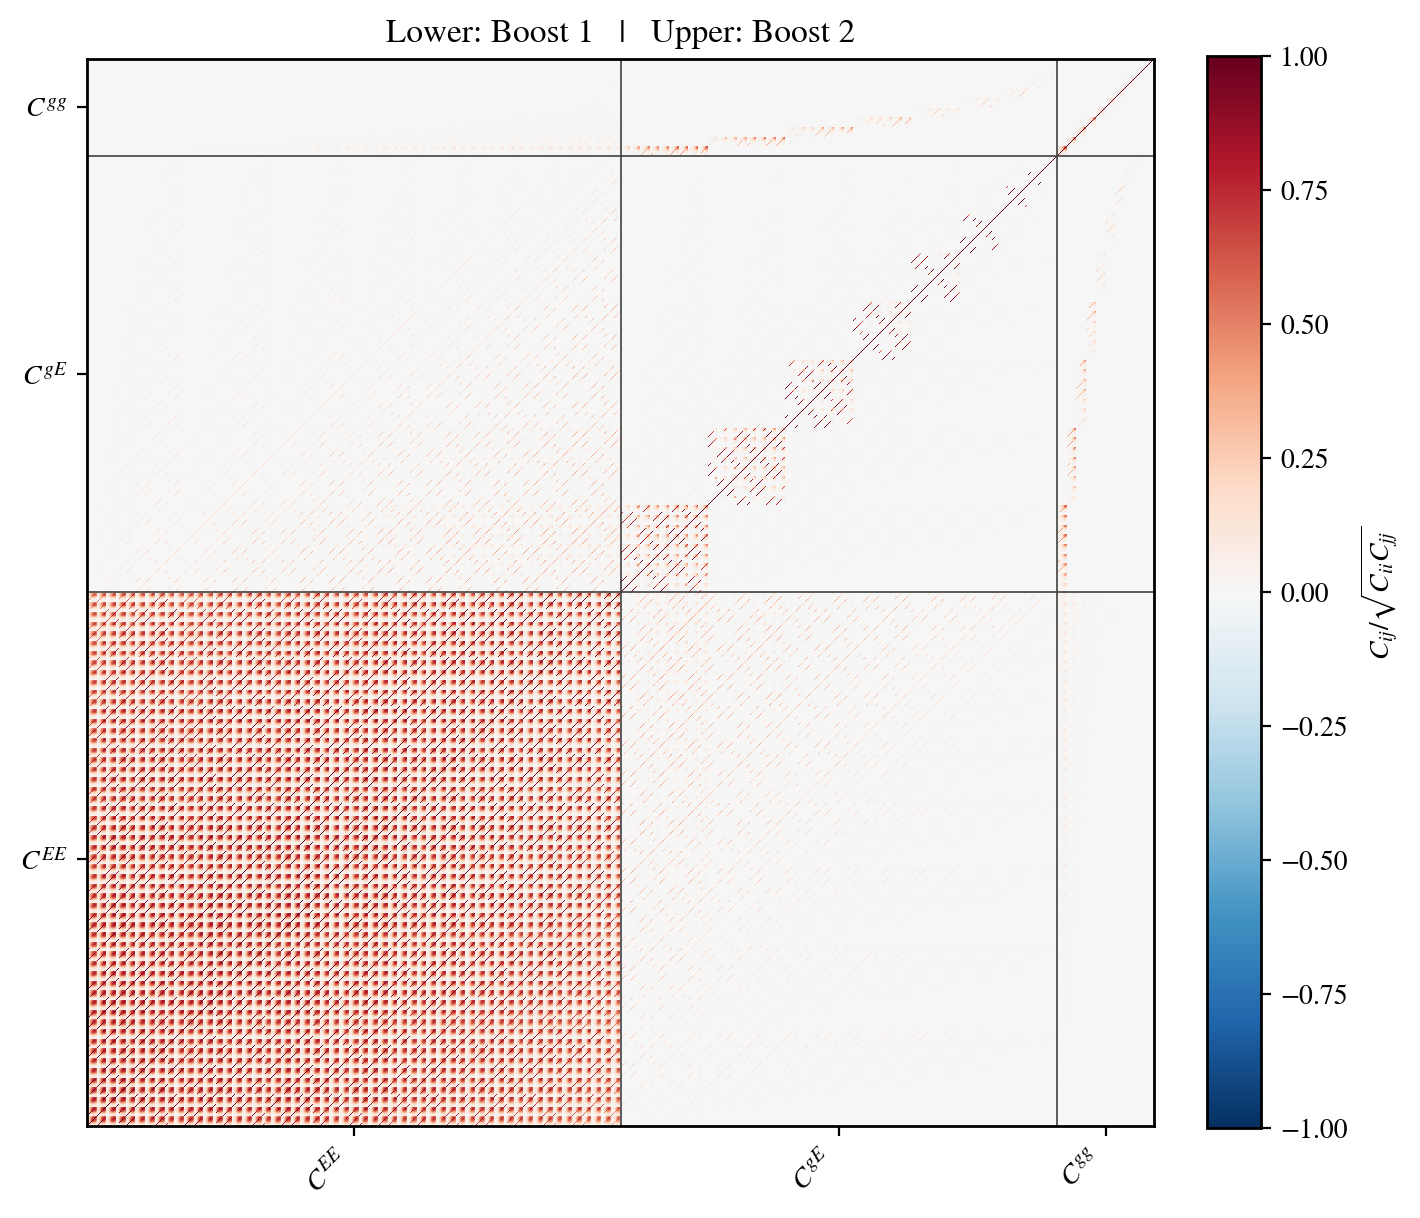

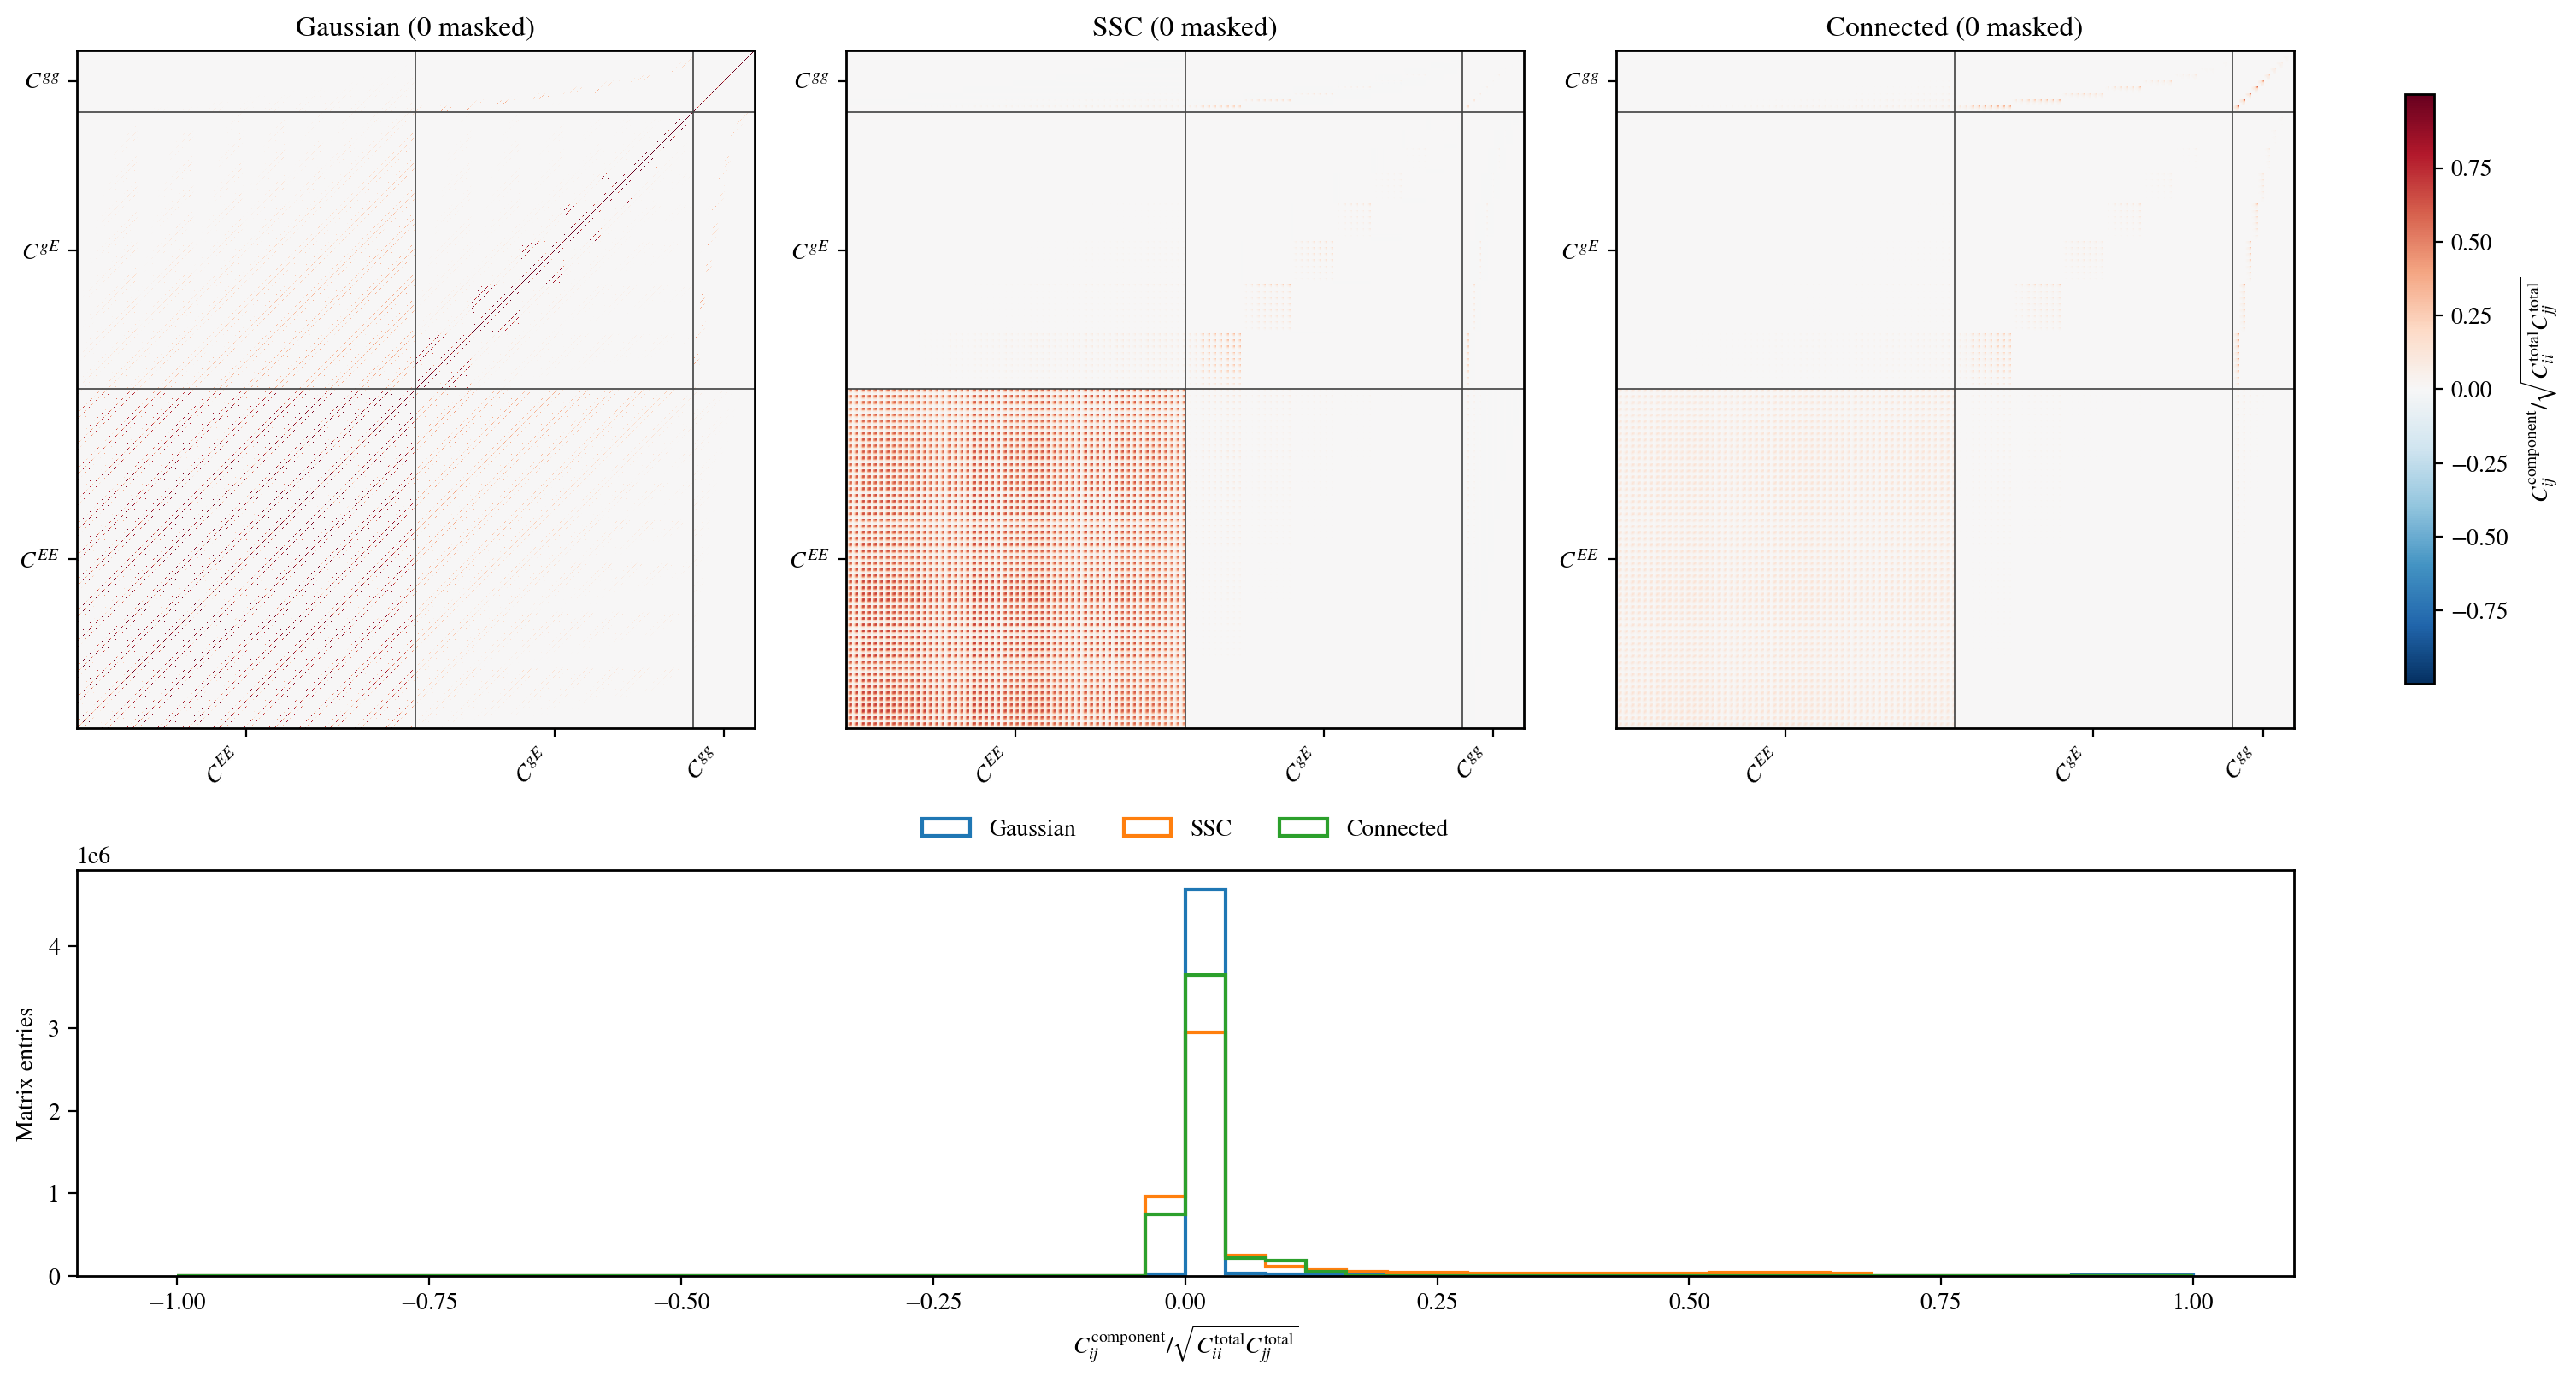

In [4]:
fourier_results = {}
for boost in boosts:
    refined = dict(settings)
    refined.update(cov.covariance_accuracy(accuracy_boost=boost))
    print("Fourier accuracy boost", boost)
    fourier_results[boost] = survey.compute(
        interface=ci, settings=refined, space="fourier", progress=progress
    )

fourier = fourier_results[reference_boost]
nband = len(fourier["coordinate"])
fourier_sizes = []
for probe in (0, 2, 3):
    fourier_sizes.append(int(np.sum(fourier["rows"][:, 0] == probe))*nband)
fourier_labels = [r"$C^{EE}$", r"$C^{gE}$", r"$C^{gg}$"]
pcov.plot_correlation(
    covariance=fourier_results[boosts[0]]["total"],
    covariance_ref=fourier["total"], block_sizes=fourier_sizes,
    block_labels=fourier_labels,
    labels=(f"Boost {boosts[0]}", f"Boost {reference_boost}"),
)
pcov.plot_covariance_components(
    total=fourier["total"],
    components={
        "Gaussian": fourier["gaussian"],
        "SSC": fourier["ssc"],
        "Connected": fourier["cng"],
    },
    block_sizes=fourier_sizes, block_labels=fourier_labels,
    normalization="diagonal",
)


## Positivity and accuracy changes

A covariance must give nonnegative variance to every linear combination
of measurements. A positive diagonal alone does not establish this. The
next cells report the total matrix's smallest correlation eigenvalue,
without clipping eigenvalues or adding diagonal corrections.

Generalized eigenvalues solve $C_bv=\lambda C_{\rm ref}v$ and bound variance
ratios in every direction. The diagonal comparison measures changes in
individual error bars. The two reported change columns are fractions: 0.01
means 1%. The error-bar plots below convert those fractions to percent. Both are diagnostics; final numerical acceptance
needs stable parameter errors and marginalized Fisher Figure of Merit at
representative cosmologies. The data-vector $|\Delta\chi^2|<0.2$ condition
is not a covariance convergence test.

The correlation panels follow
[Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568). Component maps
and histograms adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266).
The plots use the computed matrices; they retain signs and do not invent
missing components. Grey pixels mark undefined normalizations.


In [5]:
for space, results in (("Real", real_results), ("Fourier", fourier_results)):
    reference = results[reference_boost]["total"]
    print(space, "boost | minimum correlation eigenvalue |",
          "max variance change | max error change")
    for boost in boosts:
        matrix = results[boost]["total"]
        modes = cov.covariance_modes(matrix=matrix)
        print("  Positive definite:", modes["positive_definite"])
        comparison = cov.compare_covariances(matrix=matrix, reference=reference)
        errors = np.sqrt(np.diag(matrix)/np.diag(reference))
        print(boost, modes["correlation_eigenvalues"][0],
              comparison["maximum_fractional_variance_change"],
              np.max(np.abs(errors-1)))


Real boost | minimum correlation eigenvalue | max variance change | max error change


  Positive definite: True


1 4.314010678400906e-05 1.9724524786942657 0.15190558297555556


  Positive definite: True


2 4.3136388858131853e-05 2.0946533396681843e-10 0.0
Fourier boost | minimum correlation eigenvalue | max variance change | max error change


  Positive definite: True


1 5.894790870724477e-06 0.3403387570637346 0.09420007335488889


  Positive definite: True


2 5.89482588546228e-06 6.687596032506349e-10 0.0


## Error bars for the first source bin

The full matrices above retain every bin pair. For readable error-bar
panels, select the first source auto-correlation: $\xi_+$ and $\xi_-$ in
real space, and its E-mode bands in Fourier space. Each curve shows the
change in $\sqrt{C_{ii}}$ relative to the highest tested boost.


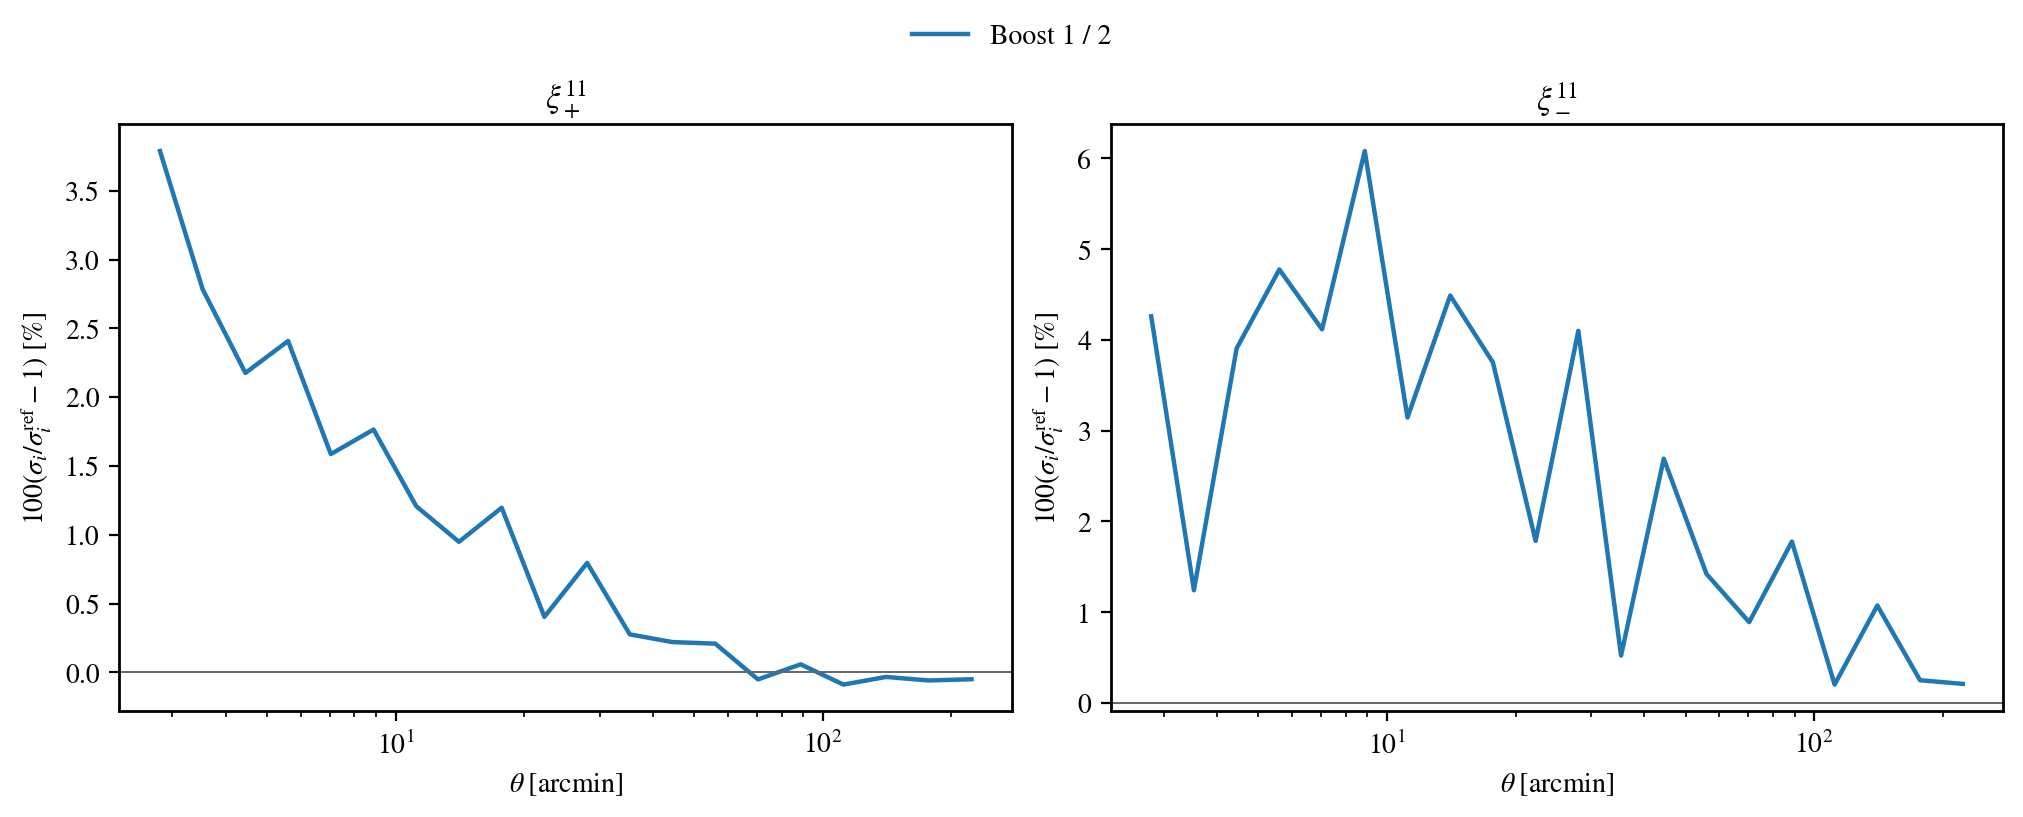

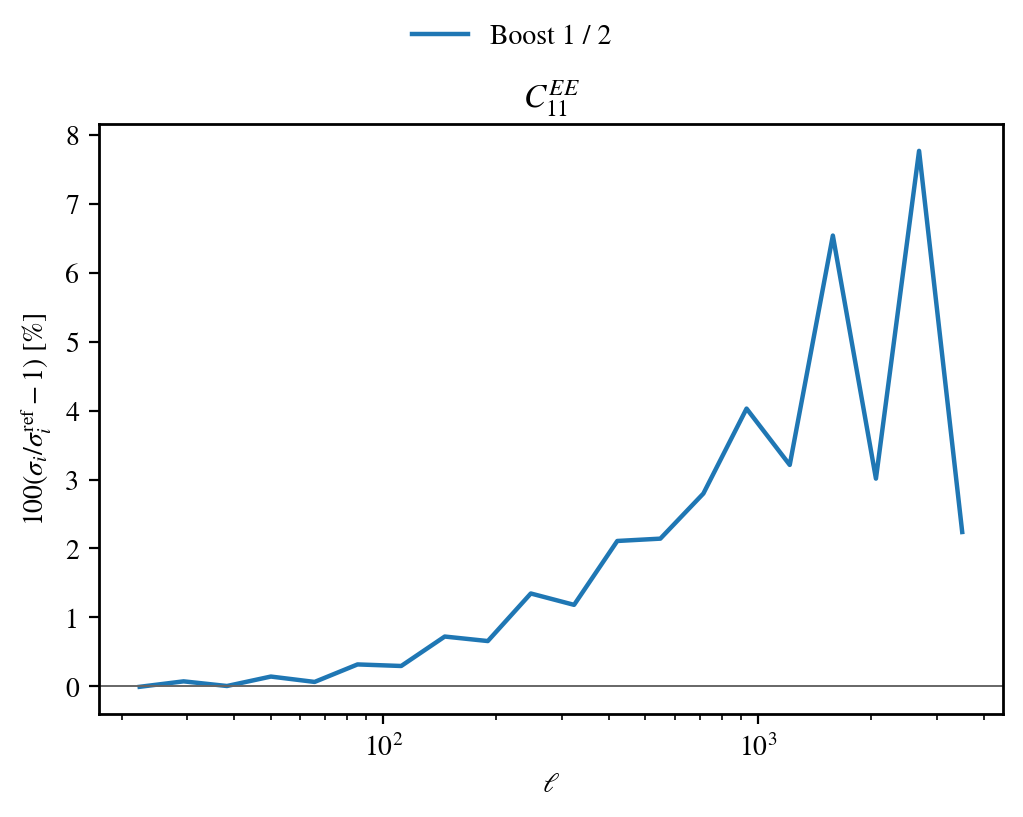

In [6]:
nlens = len(settings["lens_density_arcmin2"])
for space, results in (("Real", real_results), ("Fourier", fourier_results)):
    selected = results[reference_boost]
    rows = selected["rows"]
    source_rows = np.flatnonzero((rows[:, 1] == nlens) & (rows[:, 2] == nlens))
    nbin = len(selected["coordinate"])
    indices = (source_rows[:, None]*nbin+np.arange(nbin)).ravel()
    reference = selected["total"][np.ix_(indices, indices)]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {reference_boost}"] = (
            results[boost]["total"][np.ix_(indices, indices)]
        )
    labels = [r"$C^{EE}_{11}$"]
    if space == "Real":
        labels = [r"$\xi_+^{11}$", r"$\xi_-^{11}$"]
    pcov.plot_covariance_diagonal(
        theta_arcmin=selected["coordinate"], covariances=curves,
        panel_labels=labels, covariance_ref=reference,
        coordinate_label=selected["coordinate_label"],
    )


## Inspect the C++ interface and individual components

`ci.covariance_gaussian_real` and `ci.covariance_gaussian_fourier` accept
complete supplied field spectra, noise and measurement operators and
return owned NumPy matrices. Low-level functions expose the Wick products,
projection, halo moments, responses and mask variance for independent tests.
Their help text gives dimensions and units. The example below inspects
interfaces without altering the installed cosmology.


In [7]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)


Help on built-in function covariance_gaussian_fourier in module cosmolike_roman_kl_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: numpy.ndarray[numpy.float64], noise: numpy.ndarray[numpy.float64], pairs: numpy.ndarray[numpy.int32], operators: numpy.ndarray[numpy.float64], ell_min: int, area_sr: float) -> numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use contiguous float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vector.


## Save and inspect the computed matrices

The next cell writes the highest tested boost to two NumPy archives in
`covariance/`, and saves the CAMB tables separately. Each forecast archive
contains separate components, total, row map, mean signal, coordinates,
radial geometry and resolved numerical/physical settings. The paths refer
to these computed outputs, not the project's supplied data files.

For stronger refinement, extend `boosts` to `[1, 2, 4]` or `[1, 2, 4, 8]`
and rerun the notebook. Outputs at the same names are replaced. Refine
the physical model separately from its numerical integration.


In [8]:
save_forecast(result=real, filename=project/"covariance/forecast_real.npz")
save_forecast(result=fourier, filename=project/"covariance/forecast_fourier.npz")
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)

with np.load(project/"covariance/forecast_real.npz", allow_pickle=False) as saved:
    print("Saved arrays:", saved.files)
    print("Total covariance shape:", saved["total"].shape)


Saved arrays: ['gaussian', 'ssc', 'cng', 'total', 'signal', 'rows', 'coordinate', 'coordinate_label', 'geometry', 'coarse_ell', 'pair_area_sr2', 'settings_json', 'stages_json']
Total covariance shape: (3300, 3300)
